✓ Loaded metrics for 40 epochs


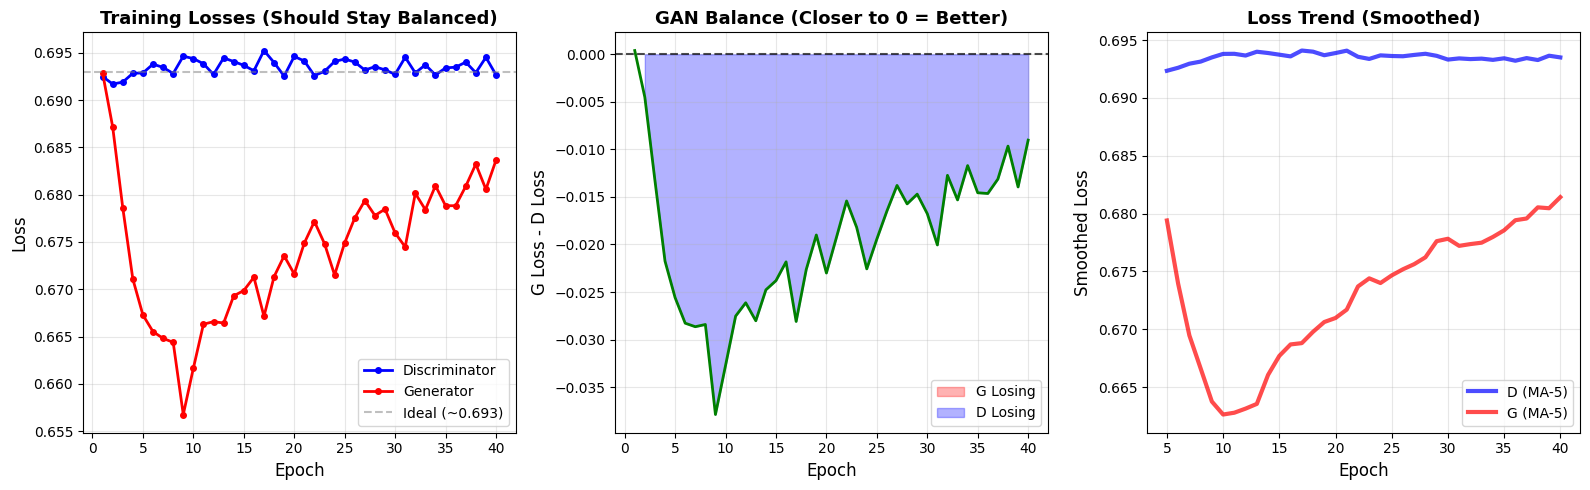


TRAINING STATISTICS SUMMARY
Final Epoch: 40

Final Losses:
  Discriminator: 0.6927
  Generator:     0.6836
  Difference:    0.0090

Last 10 Epochs Average:
  Discriminator: 0.6935 (variance: 0.000000)
  Generator:     0.6800 (variance: 0.000006)

✅ WELL BALANCED - Losses are close (Δ = 0.0090)

✓ Found 49 generated image files


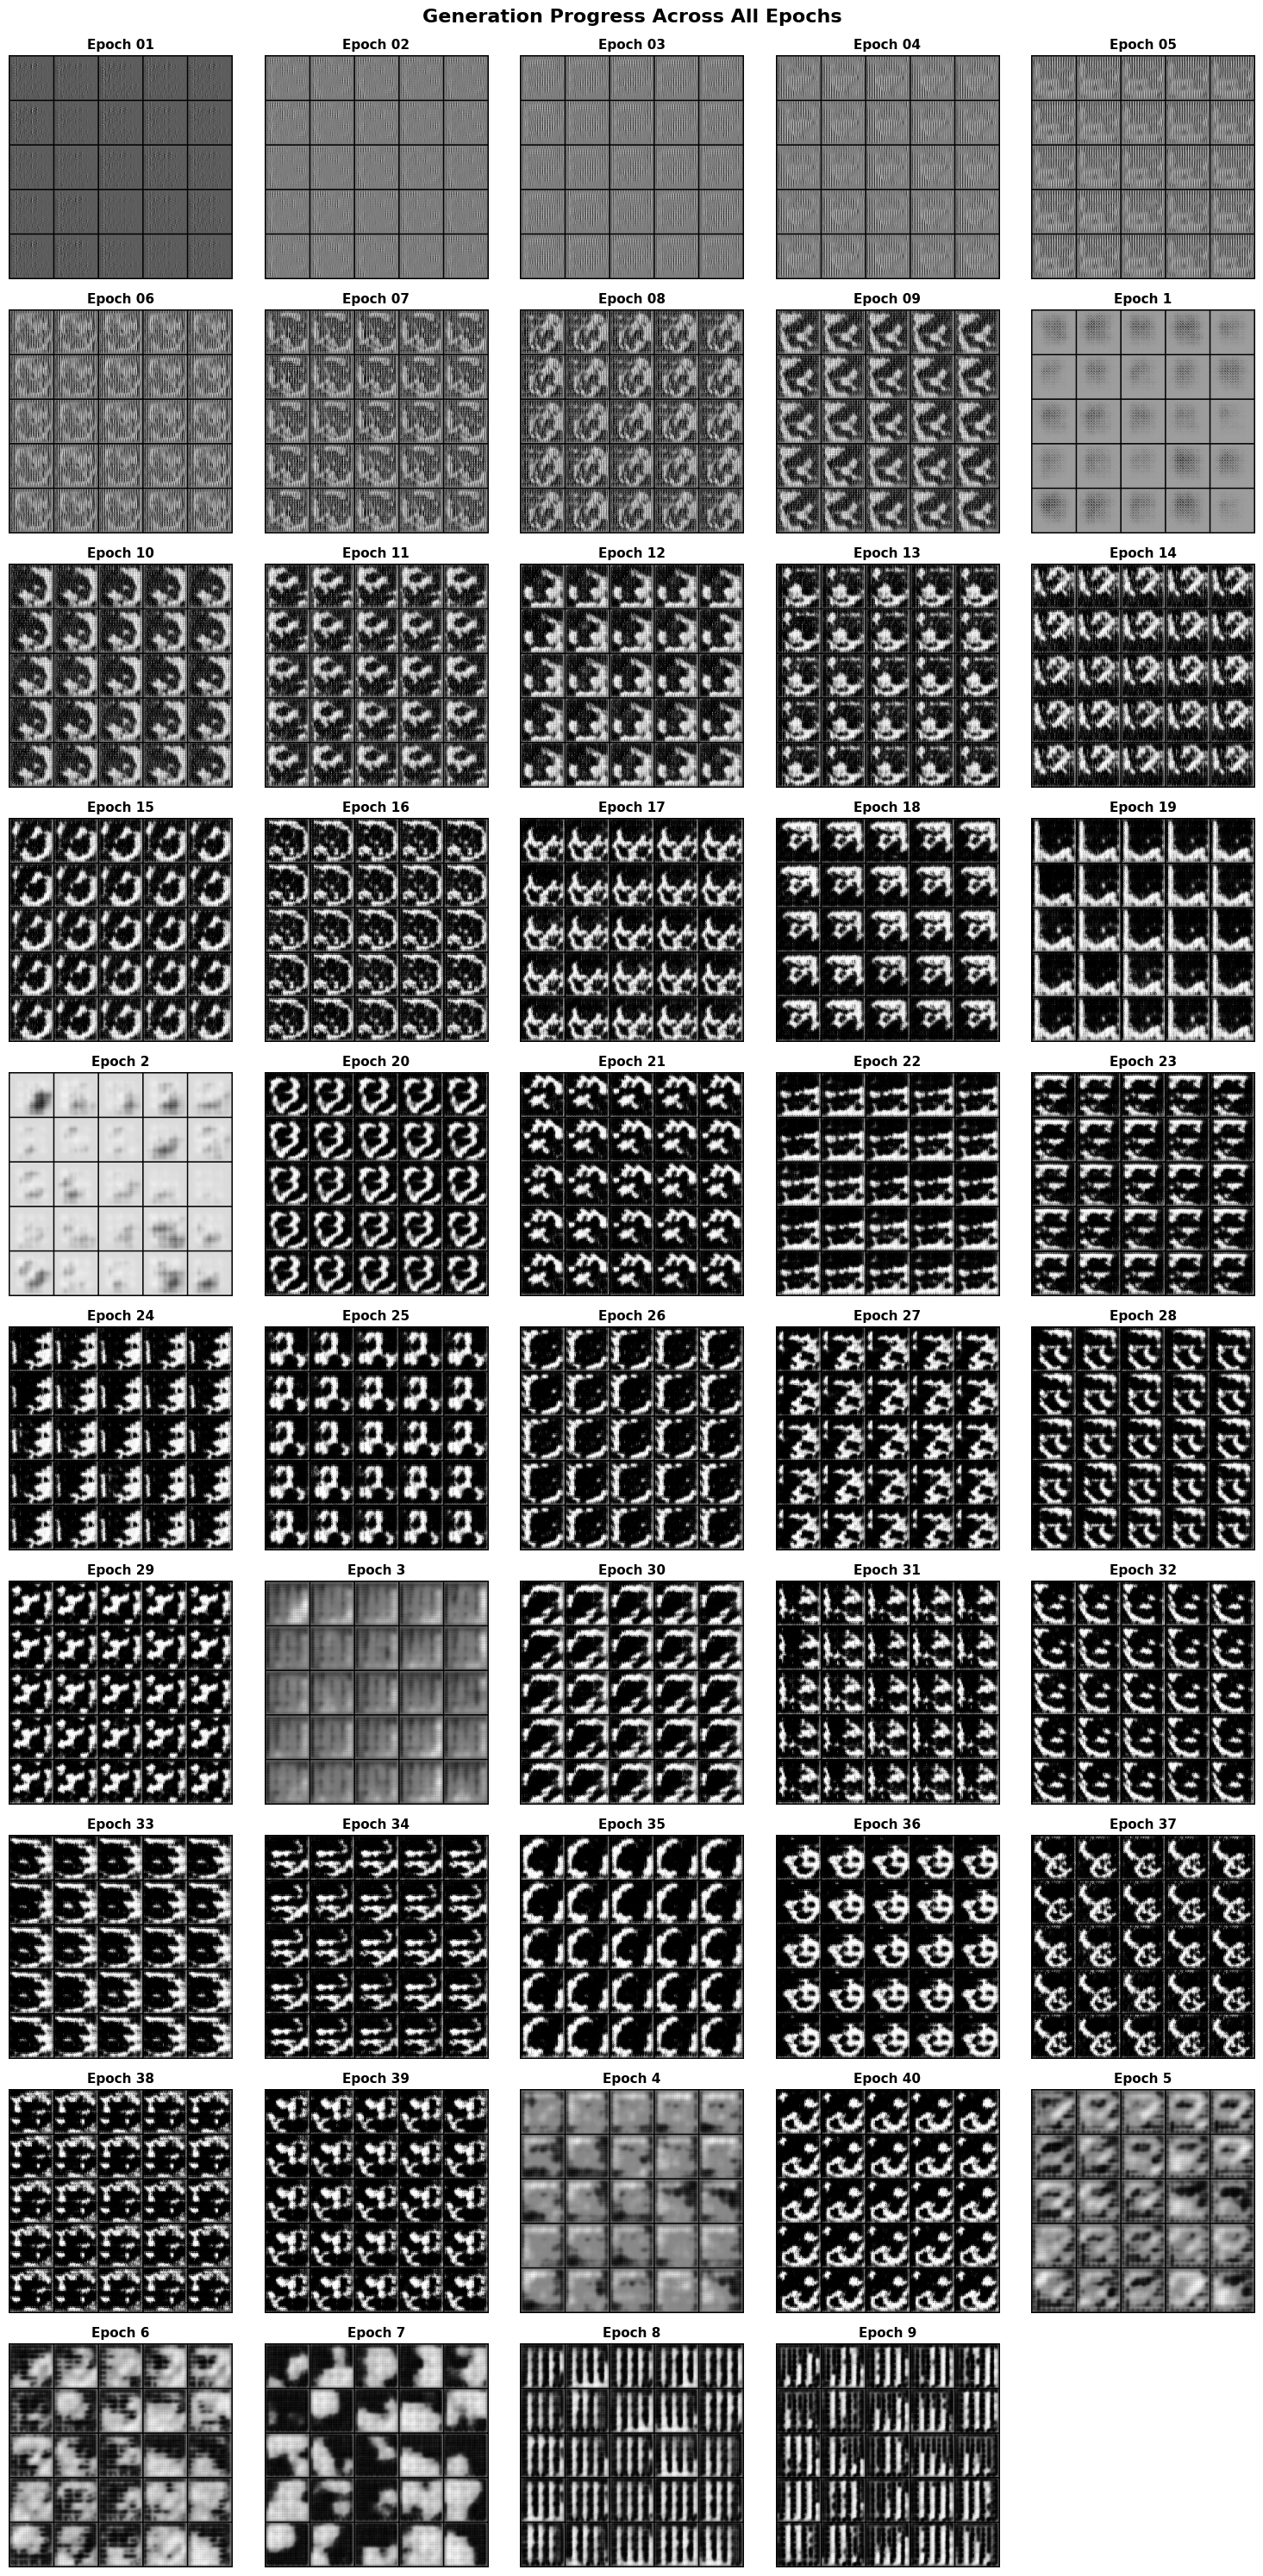


DIVERSITY CHECK - Generating Random Samples
⚠️  Could not run diversity test: Error(s) in loading state_dict for Generator:
	Missing key(s) in state_dict: "gen.0.0.depthwise.weight", "gen.0.0.pointwise.weight", "gen.0.1.weight", "gen.0.1.bias", "gen.0.1.running_mean", "gen.0.1.running_var", "gen.1.0.depthwise.weight", "gen.1.0.pointwise.weight", "gen.1.1.weight", "gen.1.1.bias", "gen.1.1.running_mean", "gen.1.1.running_var", "gen.2.0.depthwise.weight", "gen.2.0.pointwise.weight", "gen.2.1.weight", "gen.2.1.bias", "gen.2.1.running_mean", "gen.2.1.running_var", "gen.3.0.depthwise.weight", "gen.3.0.pointwise.weight", "gen.3.1.weight", "gen.3.1.bias", "gen.3.1.running_mean", "gen.3.1.running_var", "gen.4.depthwise.weight", "gen.4.pointwise.weight". 
	Unexpected key(s) in state_dict: "_orig_mod.gen.0.0.depthwise.weight", "_orig_mod.gen.0.0.pointwise.weight", "_orig_mod.gen.0.1.weight", "_orig_mod.gen.0.1.bias", "_orig_mod.gen.0.1.running_mean", "_orig_mod.gen.0.1.running_var", "_orig_mod.g

In [31]:
import matplotlib.pyplot as plt
import json
from PIL import Image
import glob
import numpy as np
import os
import torch
import torchvision.utils as vutils
from matplotlib.gridspec import GridSpec

# =============================================
# 1. Load Metrics
# =============================================
try:
    with open("checkpoints/metrics.json", "r") as f:
        metrics = json.load(f)
    print(f"✓ Loaded metrics for {len(metrics['epoch'])} epochs")
except FileNotFoundError:
    print("ERROR: checkpoints/metrics.json not found!")
    exit()

# =============================================
# 2. Advanced Loss Analysis Plot
# =============================================
fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 3, figure=fig)

# Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(metrics['epoch'], metrics['loss_d'], 'b-o', label='Discriminator', linewidth=2, markersize=4)
ax1.plot(metrics['epoch'], metrics['loss_g'], 'r-o', label='Generator', linewidth=2, markersize=4)
ax1.axhline(y=0.693, color='gray', linestyle='--', alpha=0.5, label='Ideal (~0.693)')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Losses (Should Stay Balanced)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss difference (balance indicator)
ax2 = fig.add_subplot(gs[0, 1])
loss_diff = np.array(metrics['loss_g']) - np.array(metrics['loss_d'])
ax2.plot(metrics['epoch'], loss_diff, 'g-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.7)
ax2.fill_between(metrics['epoch'], loss_diff, 0, where=(loss_diff > 0), alpha=0.3, color='red', label='G Losing')
ax2.fill_between(metrics['epoch'], loss_diff, 0, where=(loss_diff < 0), alpha=0.3, color='blue', label='D Losing')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('G Loss - D Loss', fontsize=12)
ax2.set_title('GAN Balance (Closer to 0 = Better)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Loss moving average (smoothness indicator)
ax3 = fig.add_subplot(gs[0, 2])
window = min(5, len(metrics['loss_d']) // 2)
if window > 0:
    loss_d_ma = np.convolve(metrics['loss_d'], np.ones(window)/window, mode='valid')
    loss_g_ma = np.convolve(metrics['loss_g'], np.ones(window)/window, mode='valid')
    epochs_ma = metrics['epoch'][window-1:]
    
    ax3.plot(epochs_ma, loss_d_ma, 'b-', linewidth=3, label=f'D (MA-{window})', alpha=0.7)
    ax3.plot(epochs_ma, loss_g_ma, 'r-', linewidth=3, label=f'G (MA-{window})', alpha=0.7)
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Smoothed Loss', fontsize=12)
    ax3.set_title('Loss Trend (Smoothed)', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================
# 3. Training Statistics Summary
# =============================================
print("\n" + "="*60)
print("TRAINING STATISTICS SUMMARY")
print("="*60)

final_loss_d = metrics['loss_d'][-1]
final_loss_g = metrics['loss_g'][-1]
avg_loss_d = np.mean(metrics['loss_d'][-10:])  # Last 10 epochs
avg_loss_g = np.mean(metrics['loss_g'][-10:])
loss_variance_d = np.var(metrics['loss_d'][-10:])
loss_variance_g = np.var(metrics['loss_g'][-10:])

print(f"Final Epoch: {metrics['epoch'][-1]}")
print(f"\nFinal Losses:")
print(f"  Discriminator: {final_loss_d:.4f}")
print(f"  Generator:     {final_loss_g:.4f}")
print(f"  Difference:    {abs(final_loss_g - final_loss_d):.4f}")

print(f"\nLast 10 Epochs Average:")
print(f"  Discriminator: {avg_loss_d:.4f} (variance: {loss_variance_d:.6f})")
print(f"  Generator:     {avg_loss_g:.4f} (variance: {loss_variance_g:.6f})")

# Convergence assessment
if abs(final_loss_g - final_loss_d) < 0.05:
    print(f"\n✅ WELL BALANCED - Losses are close (Δ = {abs(final_loss_g - final_loss_d):.4f})")
elif final_loss_d < 0.3:
    print(f"\n⚠️  POTENTIAL MODE COLLAPSE - Discriminator too strong (D = {final_loss_d:.4f})")
elif final_loss_g > 2.0:
    print(f"\n⚠️  GENERATOR STRUGGLING - Generator loss too high (G = {final_loss_g:.4f})")
else:
    print(f"\n✅ TRAINING APPEARS STABLE")

print("="*60 + "\n")

# =============================================
# 4. Generated Images Progression
# =============================================
image_files = sorted(glob.glob("outputs/epoch_*.png"))

if len(image_files) == 0:
    print("⚠️  No generated images found in outputs/")
else:
    num_images = len(image_files)
    print(f"✓ Found {num_images} generated image files")
    
    # Determine grid size
    cols = 5
    rows = int(np.ceil(num_images / cols))
    
    plt.figure(figsize=(cols * 3, rows * 3))
    
    for idx, img_path in enumerate(image_files):
        img = Image.open(img_path)
        epoch_num = os.path.basename(img_path).split("_")[1].split(".")[0]
        
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Epoch {epoch_num}", fontsize=11, fontweight='bold')
        ax.axis('off')
        
        # Add border to emphasize
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(1)
    
    plt.suptitle('Generation Progress Across All Epochs', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('generated_images_progression.png', dpi=150, bbox_inches='tight')
    plt.show()

# =============================================
# 5. DIVERSITY TEST - Random Sampling
# =============================================
print("\n" + "="*60)
print("DIVERSITY CHECK - Generating Random Samples")
print("="*60)

try:
    # Load the model
    from train import Generator  # Import from your training script
    
    gen = Generator(100, 1, 64).cuda()
    gen.load_state_dict(torch.load('checkpoints/generator_final.pth'))
    gen.eval()
    
    print("✓ Model loaded successfully")
    
    # Generate diverse samples from different latent regions
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))
    
    samples_all = []
    
    for i in range(50):
        # Sample from different regions of latent space
        noise = torch.randn(1, 100, 1, 1).cuda()
        # Vary the scale to explore different regions
        scale = 0.5 + (i / 50) * 1.5  # Scale from 0.5 to 2.0
        noise = noise * scale
        
        with torch.no_grad():
            img = gen(noise)
            samples_all.append(img)
        
        row = i // 10
        col = i % 10
        axes[row, col].imshow(img[0, 0].cpu().numpy(), cmap='gray')
        axes[row, col].axis('off')
    
    plt.suptitle('50 Random Samples - Diversity Check\n(Should show multiple different Bengali digits)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('diversity_check_50_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save a grid for easier viewing
    samples_tensor = torch.cat(samples_all, dim=0)
    grid = vutils.make_grid(samples_tensor[:50], nrow=10, normalize=True)
    vutils.save_image(grid, 'diversity_grid.png')
    
    print("✓ Saved 50 random samples")
    print("✓ Check 'diversity_check_50_samples.png' and 'diversity_grid.png'")
    print("\nLook for:")
    print("  - Multiple different digit shapes")
    print("  - Variations in strokes and curves")
    print("  - If ALL samples look identical → Mode collapse")
    print("  - If you see 3-5+ different patterns → Good diversity")
    
except Exception as e:
    print(f"⚠️  Could not run diversity test: {e}")
    print("   Make sure Generator class is accessible and model file exists")

# =============================================
# 6. Final Summary
# =============================================
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("Generated files:")
print("  📊 training_loss_analysis.png")
print("  🖼️  generated_images_progression.png")
print("  🎲 diversity_check_50_samples.png")
print("  🎲 diversity_grid.png")
print("="*60)


In [39]:
%%writefile train2.py
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import numpy as np
from tqdm import tqdm
import json

# ==========================================
# 1. Model Definitions (Depthwise Separable - RESTORED)
# ==========================================
class DepthwiseSeparableConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, bias=False):
        super().__init__()
        # Depthwise: Groups = in_c (each channel convolved independently)
        self.depthwise = nn.Conv2d(in_c, in_c, k, s, p, groups=in_c, bias=bias)
        # Pointwise: Mixes channels
        self.pointwise = nn.Conv2d(in_c, out_c, 1, 1, 0, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class DepthwiseSeparableConvTranspose2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, bias=False):
        super().__init__()
        # Depthwise Transpose
        self.depthwise = nn.ConvTranspose2d(in_c, in_c, k, s, p, groups=in_c, bias=bias)
        # Pointwise
        self.pointwise = nn.Conv2d(in_c, out_c, 1, 1, 0, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super().__init__()
        self.gen = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            self._block(z_dim, features_g * 16, 4, 1, 0),  # 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1),  # 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1),  # 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1),  # 32x32
            # Final Layer
            DepthwiseSeparableConvTranspose2d(features_g * 2, channels_img, 4, 2, 1, bias=False), # 64x64
            nn.Tanh(),
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            DepthwiseSeparableConvTranspose2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.gen(x)

class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super().__init__()
        self.disc = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            DepthwiseSeparableConv2d(channels_img, features_d, 4, 2, 1, bias=False), # 32x32
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 16x16
            self._block(features_d * 2, features_d * 4, 4, 2, 1), # 8x8
            self._block(features_d * 4, features_d * 8, 4, 2, 1), # 4x4
            # Final Layer
            DepthwiseSeparableConv2d(features_d * 8, 1, 4, 2, 0, bias=False), # 1x1
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            DepthwiseSeparableConv2d(in_c, out_c, k, s, p, bias=False),
            # InstanceNorm is CRITICAL for lightweight/depthwise stability
            nn.InstanceNorm2d(out_c, affine=True), 
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.disc(x)

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

# ==========================================
# 2. Dataset Definition
# ==========================================
class BanglaDigitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Root dir not found: {root_dir}")

        for label in range(10):
            label_dir = os.path.join(root_dir, str(label))
            if os.path.isdir(label_dir):
                for img_name in os.listdir(label_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(label_dir, img_name))
        
        if len(self.image_paths) == 0:
            self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.jpg'), recursive=True) + \
                               glob.glob(os.path.join(root_dir, '**', '*.png'), recursive=True)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"FATAL: No images found in {root_dir}!")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('L')
            if self.transform:
                image = self.transform(image)
            return image, 0
        except Exception:
            return torch.zeros((1, 64, 64)), 0

# ==========================================
# 3. DDP Setup
# ==========================================
def ddp_setup(rank, world_size):
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)

# ==========================================
# 4. Training Function
# ==========================================
def train_fn(rank, world_size, hp):
    ddp_setup(rank, world_size)
    
    if rank == 0:
        os.makedirs("outputs", exist_ok=True)
        os.makedirs("checkpoints", exist_ok=True)
    
    transform = transforms.Compose([
        transforms.Resize((hp['IMAGE_SIZE'], hp['IMAGE_SIZE'])),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    
    possible_paths = [
        "/kaggle/input/bengali-digits/bengali_digits",
        "/kaggle/input/bengali-digits",
        "/kaggle/input/numta/training-a"
    ]
    
    dataset = None
    for path in possible_paths:
        if os.path.exists(path):
            try:
                dataset = BanglaDigitDataset(root_dir=path, transform=transform)
                if len(dataset) > 0:
                    if rank == 0: 
                        print(f"✓ Loaded {len(dataset)} images from: {path}")
                    break
            except Exception:
                continue
    
    if dataset is None or len(dataset) == 0:
        if rank == 0: 
            print("ERROR: No valid dataset found!")
        destroy_process_group()
        return

    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    dataloader = DataLoader(
        dataset, 
        batch_size=hp['BATCH_SIZE'], 
        shuffle=False, 
        sampler=sampler,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    # Initialize models (DEPTHWISE)
    gen = Generator(hp['NOISE_DIM'], hp['CHANNELS_IMG'], hp['FEATURES_GEN']).to(rank)
    disc = Discriminator(hp['CHANNELS_IMG'], hp['FEATURES_DISC']).to(rank)
    
    gen.apply(initialize_weights)
    disc.apply(initialize_weights)

    gen = DDP(gen, device_ids=[rank])
    disc = DDP(disc, device_ids=[rank])

    # Optimizers - EQUAL LEARNING RATES (Fixes Starvation)
    opt_gen = optim.Adam(gen.parameters(), lr=hp['LEARNING_RATE_G'], betas=(hp['BETA_1'], hp['BETA_2']))
    opt_disc = optim.Adam(disc.parameters(), lr=hp['LEARNING_RATE_D'], betas=(hp['BETA_1'], hp['BETA_2']))
    
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler('cuda')
    fixed_noise = torch.randn(32, hp['NOISE_DIM'], 1, 1).to(rank)
    
    metrics = {'epoch': [], 'loss_d': [], 'loss_g': []}
    
    if rank == 0:
        print(f"🚀 Training Depthwise GAN: {world_size} GPUs | Batch: {hp['BATCH_SIZE']}/GPU")

    # ==========================================
    # 5. Training Loop
    # ==========================================
    for epoch in range(hp['NUM_EPOCHS']):
        sampler.set_epoch(epoch)
        
        iterator = tqdm(dataloader, desc=f"Epoch {epoch+1}/{hp['NUM_EPOCHS']}", disable=(rank != 0))
        
        epoch_loss_d = []
        epoch_loss_g = []
        
        for batch_idx, (real, _) in enumerate(iterator):
            real = real.to(rank, non_blocking=True)
            curr_batch_size = real.shape[0]
            
            # --- Train Discriminator (EVERY STEP - NO SKIPPING) ---
            with torch.amp.autocast('cuda'):
                noise = torch.randn(curr_batch_size, hp['NOISE_DIM'], 1, 1).to(rank)
                fake = gen(noise)
                disc_real = disc(real).reshape(-1)
                
                # Soft labels
                real_labels = torch.rand(curr_batch_size, device=rank) * 0.1 + 0.9 
                fake_labels = torch.rand(curr_batch_size, device=rank) * 0.1     
                
                loss_disc_real = criterion(disc_real, real_labels)
                disc_fake = disc(fake.detach()).reshape(-1)
                loss_disc_fake = criterion(disc_fake, fake_labels)
                loss_disc = (loss_disc_real + loss_disc_fake) / 2

            opt_disc.zero_grad(set_to_none=True)
            scaler.scale(loss_disc).backward()
            scaler.step(opt_disc)
            
            epoch_loss_d.append(loss_disc.item())

            # --- Train Generator ---
            with torch.amp.autocast('cuda'):
                output = disc(fake).reshape(-1)
                loss_gen = criterion(output, torch.ones_like(output))

            opt_gen.zero_grad(set_to_none=True)
            scaler.scale(loss_gen).backward()
            scaler.step(opt_gen)
            scaler.update()
            
            epoch_loss_g.append(loss_gen.item())

            if rank == 0 and batch_idx % 10 == 0:
                iterator.set_postfix(D=f"{loss_disc.item():.3f}", G=f"{loss_gen.item():.3f}")

        # Save metrics and images
        if rank == 0:
            avg_loss_d = np.mean(epoch_loss_d)
            avg_loss_g = np.mean(epoch_loss_g)
            metrics['epoch'].append(epoch + 1)
            metrics['loss_d'].append(avg_loss_d)
            metrics['loss_g'].append(avg_loss_g)
            
            with torch.no_grad():
                fake_viz = gen(fixed_noise)
                vutils.save_image(fake_viz[:25], f"outputs/epoch_{epoch+1:02d}.png", nrow=5, normalize=True)
            
            print(f"✓ Epoch {epoch+1} | D: {avg_loss_d:.4f} | G: {avg_loss_g:.4f}")
            
            if (epoch + 1) % 5 == 0:
                torch.save({
                    'epoch': epoch + 1,
                    'generator_state_dict': gen.module.state_dict(),
                    'discriminator_state_dict': disc.module.state_dict(),
                }, f"checkpoints/checkpoint_epoch_{epoch+1:02d}.pth")
                print(f"💾 Checkpoint saved")

    if rank == 0:
        torch.save(gen.module.state_dict(), "checkpoints/generator_final.pth")
        torch.save(disc.module.state_dict(), "checkpoints/discriminator_final.pth")
        with open("checkpoints/metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)
        print("✅ Training complete!")

    destroy_process_group()

# ==========================================
# 6. Main Entry Point
# ==========================================
if __name__ == '__main__':
    hyperparameters = {
        'LEARNING_RATE_G': 2e-4,     # FIXED: Equal to D
        'LEARNING_RATE_D': 2e-4,     # FIXED: Not 5e-5
        'BATCH_SIZE': 128,
        'IMAGE_SIZE': 64,
        'CHANNELS_IMG': 1,
        'NOISE_DIM': 100,
        'FEATURES_DISC': 64,
        'FEATURES_GEN': 64,
        'NUM_EPOCHS': 50,
        'BETA_1': 0.5,
        'BETA_2': 0.999
    }
    
    world_size = torch.cuda.device_count()
    if world_size > 1:
        mp.spawn(train_fn, args=(world_size, hyperparameters), nprocs=world_size)
    else:
        train_fn(0, 1, hyperparameters)

Overwriting train2.py


In [40]:
!python train2.py

✓ Loaded 15620 images from: /kaggle/input/bengali-digits/bengali_digits
🚀 Training Depthwise GAN: 2 GPUs | Batch: 128/GPU
Epoch 1/50: 100%|█████████████| 62/62 [00:22<00:00,  2.76it/s, D=0.196, G=2.569]
✓ Epoch 1 | D: 0.4300 | G: 1.3500
Epoch 2/50: 100%|█████████████| 62/62 [00:07<00:00,  8.58it/s, D=0.267, G=2.864]
✓ Epoch 2 | D: 0.2266 | G: 2.8777
Epoch 3/50: 100%|█████████████| 62/62 [00:07<00:00,  8.49it/s, D=0.476, G=2.726]
✓ Epoch 3 | D: 0.3345 | G: 2.7132
Epoch 4/50: 100%|█████████████| 62/62 [00:07<00:00,  8.45it/s, D=0.461, G=2.174]
✓ Epoch 4 | D: 0.4149 | G: 2.2584
Epoch 5/50: 100%|█████████████| 62/62 [00:07<00:00,  8.65it/s, D=0.548, G=1.231]
✓ Epoch 5 | D: 0.5227 | G: 1.5086
💾 Checkpoint saved
Epoch 6/50: 100%|█████████████| 62/62 [00:07<00:00,  8.47it/s, D=0.608, G=1.298]
✓ Epoch 6 | D: 0.5722 | G: 1.0630
Epoch 7/50: 100%|█████████████| 62/62 [00:07<00:00,  8.21it/s, D=0.609, G=1.308]
✓ Epoch 7 | D: 0.5828 | G: 1.0110
Epoch 8/50: 100%|█████████████| 62/62 [00:07<00:00,  8

In [41]:
import matplotlib.pyplot as plt
import json
import os
import glob
import math
from PIL import Image
import numpy as np

# ==========================================
# 1. Configuration
# ==========================================
# These match the folders created by train1.py
METRICS_PATH = "checkpoints/metrics.json" 
OUTPUT_DIR = "outputs"                     
SAVE_DIR = "visualizations"                

os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. Plot Training Loss (Paper Ready)
# ==========================================
def plot_metrics(json_path):
    if not os.path.exists(json_path):
        print(f"❌ Metrics file not found at {json_path}. Run training first!")
        return

    with open(json_path, 'r') as f:
        data = json.load(f)

    epochs = data['epoch']
    loss_d = data['loss_d']
    loss_g = data['loss_g']

    # Smoothing helper
    def smooth(scalars, weight=0.7):
        last = scalars[0]
        smoothed = []
        for point in scalars:
            smoothed_val = last * weight + (1 - weight) * point
            smoothed.append(smoothed_val)
            last = smoothed_val
        return smoothed

    plt.figure(figsize=(10, 6), dpi=150)
    
    # Plot Raw Data (Light)
    plt.plot(epochs, loss_d, alpha=0.2, color='blue', linewidth=1)
    plt.plot(epochs, loss_g, alpha=0.2, color='red', linewidth=1)
    
    # Plot Smoothed Data (Bold)
    plt.plot(epochs, smooth(loss_d), color='blue', linewidth=2.5, label='Discriminator Loss (Depthwise)')
    plt.plot(epochs, smooth(loss_g), color='red', linewidth=2.5, label='Generator Loss (Depthwise)')
    
    # Ideal Equilibrium Line
    plt.axhline(y=0.693, color='black', linestyle='--', alpha=0.5, linewidth=1, label='Ideal Nash Equilibrium')
    
    plt.title("Depthwise GAN Training Stability", fontsize=14, fontweight='bold')
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("BCE Loss", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_path = os.path.join(SAVE_DIR, "depthwise_training_loss.png")
    plt.savefig(save_path)
    print(f"✓ Loss plot saved to: {save_path}")
    plt.close()

# ==========================================
# 3. Create Evolution Grid (Paper Ready)
# ==========================================
def create_evolution_grid(img_dir, max_epochs_to_show=20):
    images = glob.glob(os.path.join(img_dir, "epoch_*.png"))
    if not images:
        print(f"❌ No images found in {img_dir}")
        return

    # Sort numerically by epoch number
    try:
        images.sort(key=lambda x: int(os.path.basename(x).split('_')[1].split('.')[0]))
    except:
        images.sort()

    # Pick a subset of images evenly spaced
    total_images = len(images)
    if total_images > max_epochs_to_show:
        indices = np.linspace(0, total_images - 1, max_epochs_to_show, dtype=int)
        selected_images = [images[i] for i in indices]
    else:
        selected_images = images

    # Grid calculations
    num_plots = len(selected_images)
    cols = 5
    rows = math.ceil(num_plots / cols)

    plt.figure(figsize=(cols * 2.5, rows * 2.8))
    plt.suptitle("Evolution of Generated Bengali Digits (Depthwise GAN)", fontsize=16, y=1.02)

    for i, img_path in enumerate(selected_images):
        img = Image.open(img_path)
        epoch_num = os.path.basename(img_path).split('_')[1].split('.')[0]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Epoch {epoch_num}", fontsize=10)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, "depthwise_evolution_grid.png")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"✓ Evolution grid saved to: {save_path}")
    plt.close()

# ==========================================
# Run
# ==========================================
if __name__ == "__main__":
    print("🎨 Generating Plots for Research Paper...")
    plot_metrics(METRICS_PATH)
    create_evolution_grid(OUTPUT_DIR)
    print(f"✅ Done! Check the '{SAVE_DIR}' folder.")

🎨 Starting Visualization Process...
✓ Loss plot saved to: visualizations/training_loss_plot.png
✓ Found 59 epoch snapshots.
✓ Evolution montage saved to: visualizations/generation_progression.png
✅ Visualization complete! Check the 'visualizations' folder.
